# Assignment 2

Name : Ashwin Kharat

Rollno : 241310004

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import sympy as sp

## Q1.  Monte-Carlo Integration:

Compute the integrals using the Monte Carlo method and explain the results.


In [40]:

def monte_carlo(func_exp,a,b,n):
    x = sp.symbols('x')
    func = sp.lambdify(x, func_exp, 'numpy') 

    count = 0
    try : 
        x_rand = np.random.uniform(a,b,n)
        y_rand = np.random.uniform(func(a),func(b),n)
    except:
        print("Error in the function")


    x_undercurve = []
    y_undercurve = []
    x_overcurve = []
    y_overcurve = []

    for i in range(n):
        if y_rand[i] <= func(x_rand[i]):
            count += 1
            x_undercurve.append(x_rand[i])
            y_undercurve.append(y_rand[i])
        else:
            x_overcurve.append(x_rand[i])
            y_overcurve.append(y_rand[i])

    xline = np.linspace(a, b, 200)
    yline = func(xline)
    plt.plot(x_undercurve, y_undercurve, 'bo', label='Under curve')
    plt.plot(x_overcurve, y_overcurve, 'ro', label='Over curve')
    plt.plot(xline, yline , "-k", label= f' f(x) =  {func_exp} ')

    plt.legend()
    return count/n*(b-a)*func(b)



### a.

\begin{equation*} 
\quad I_1 = \int_0^1 \sqrt{x} \, dx = \frac{2}{3}, 
\end{equation*}


Integral of sqrt(x) from 0 to 1 for n = 1000 is  = 0.67
True value of integral of sqrt(x) from 0 to 1 is  = 2/3
Error in the value of integral is = 0.00333333333333341


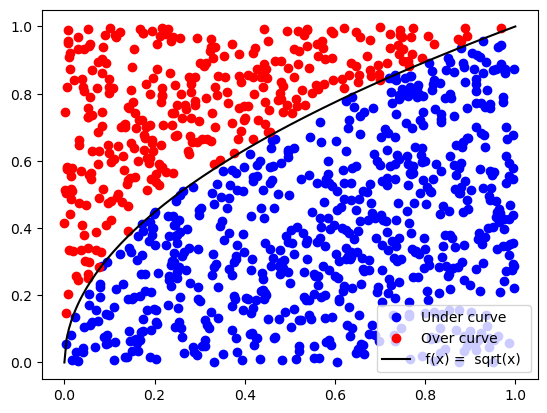

In [12]:


x = sp.symbols('x')
func_exp = sp.sqrt(x)

a = 0
b = 1
n = 1000
h = (b-a)/n

I1 = monte_carlo(func_exp,a,b,n)

true_value = sp.integrate(func_exp, (x,a,b))

error_value = abs(I1 - true_value)

print(f"Integral of {func_exp} from {a} to {b} for n = {n} is  = {I1}")
print(f"True value of integral of {func_exp} from {a} to {b} is  = {true_value}")
print(f"Error in the value of integral is = {error_value}")



### b.


\begin{equation*}
 \quad I_2 = \int_0^1 \frac{1}{\sqrt{x}} \, dx = 2,
\end{equation*}


In [41]:
import numpy as np
import matplotlib.pyplot as plt
import random as rd
import sympy as sp

def monte_carlo(func_exp,a,b,n):
    x = sp.symbols('x')
    func = sp.lambdify(x, func_exp, 'numpy') 

    count = 0
    try : 
        x_rand = np.random.uniform(a,b,n)
        y_rand = np.random.uniform(func(a),func(b),n)
    except:
        print("Error in the function")
        a = max(a,0.2)
        x_rand = np.random.uniform(a,b,n)
        y_rand = np.random.uniform(func(a),func(b),n)

    x_undercurve = []
    y_undercurve = []
    x_overcurve = []
    y_overcurve = []

    for i in range(n):
        if y_rand[i] <= func(x_rand[i]):
            count += 1
            x_undercurve.append(x_rand[i])
            y_undercurve.append(y_rand[i])
        else:
            x_overcurve.append(x_rand[i])
            y_overcurve.append(y_rand[i])

    xline = np.linspace(a, b, 200)
    yline = func(xline)
    plt.plot(x_undercurve, y_undercurve, 'bo', label='Under curve')
    plt.plot(x_overcurve, y_overcurve, 'ro', label='Over curve')
    plt.plot(xline, yline , "-k", label= f' f(x) =  {func_exp} ')
    plt.legend()
    
    return count/n * (b - a) * func(b)


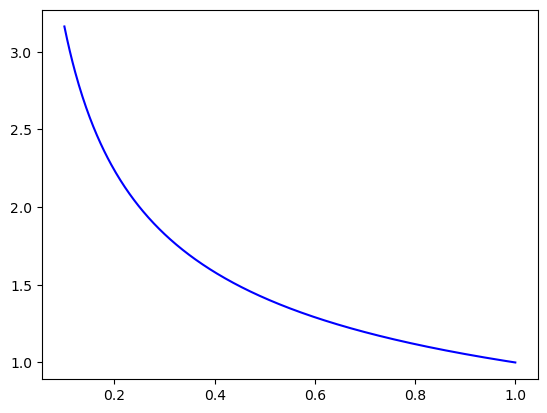

<lambdifygenerated-37>:2: RuntimeWarning: divide by zero encountered in scalar divide
  return 1/sqrt(x)


Error in the function
Integral of 1/sqrt(x) from 0 to 1 for n = 10000 is  = 0.563744245889331
True value of integral of 1/sqrt(x) from 0 to 1 is  = 2
Error in the value of integral is = 1.43625575411067


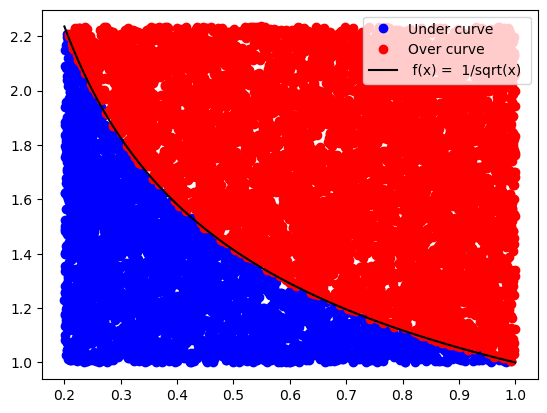

In [39]:


x = sp.symbols('x')
func_exp = 1/sp.sqrt(x)

a = 0
b = 1
n = 10000
h = (b-a)/n

# Convert the symbolic expression to a numerical function
func = sp.lambdify(x, func_exp, 'numpy')

# Define the range of x values, avoiding x = 0
x_vals = np.linspace(0.1, 1, 500)  # Start slightly above 0 to avoid singularity
y_vals = func(x_vals)
plt.plot(x_vals, y_vals, label=r"$f(x) = \frac{1}{\sqrt{x}}$", color="blue")
plt.show()

I1 = monte_carlo(func_exp,a,b,n)

true_value = sp.integrate(func_exp, (x,a,b))

error_value = abs(I1 - true_value)

print(f"Integral of {func_exp} from {a} to {b} for n = {n} is  = {I1}")
print(f"True value of integral of {func_exp} from {a} to {b} is  = {true_value}")
print(f"Error in the value of integral is = {error_value}")



In [26]:
import numpy as np
import sympy as sp

def monte_carlo(func_exp, a, b, n, epsilon=1e-6):
    """
    Perform Monte Carlo integration for a given function.
    
    Parameters:
        func_exp (sympy expression): The function to integrate.
        a (float): Lower bound of integration.
        b (float): Upper bound of integration.
        n (int): Number of random points to sample.
        epsilon (float): Small offset to avoid singularity at a.
    
    Returns:
        float: Approximation of the integral.
    """
    x = sp.symbols('x')
    func = sp.lambdify(x, func_exp, 'numpy')  # Convert symbolic to numerical
    
    # Adjust lower bound to avoid singularity at x = 0
    a = max(a, epsilon)
    
    # Generate random x values
    x_rand = np.random.uniform(a, b, n)
    
    # Determine y_max based on the maximum of func within [a, b]
    y_max = func(a)  # Maximum occurs near the lower bound for this function
    
    # Generate random y values
    y_rand = np.random.uniform(0, y_max, n)
    
    # Count points under the curve
    under_curve = y_rand <= func(x_rand)
    area_under_curve = np.sum(under_curve) / n * (b - a) * y_max

    return area_under_curve

# Define the function and integration bounds
x = sp.symbols('x')
func_exp = 1 / sp.sqrt(x)
a = 0
b = 1
n = 10000  # Number of random points

# Perform Monte Carlo integration
I1 = monte_carlo(func_exp, a, b, n)

# Calculate the true value for comparison
true_value = sp.integrate(func_exp, (x, a, b))

# Print results
print(f"Monte Carlo approximation: {I1}")
print(f"True value: {true_value}")
print(f"Error: {abs(I1 - true_value)}")


Monte Carlo approximation: 1.5999984
True value: 2
Error: 0.400001600000000


### c. 

\begin{equation*}
 \quad I_3 = \int_0^1 \frac{1}{\sqrt{x^{3/2}}} \, dx = 4,
\end{equation*}

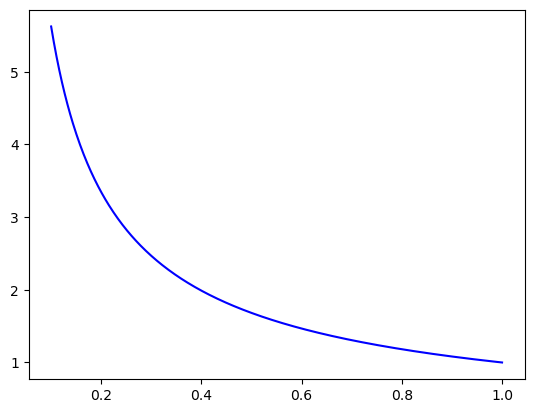

Error in the function
Integral of x**(-0.75) from 0 to 1 for n = 10000 is  = 0.22432
True value of integral of x**(-0.75) from 0 to 1 is  = 4.00000000000000
Error in the value of integral is = 3.77568000000000


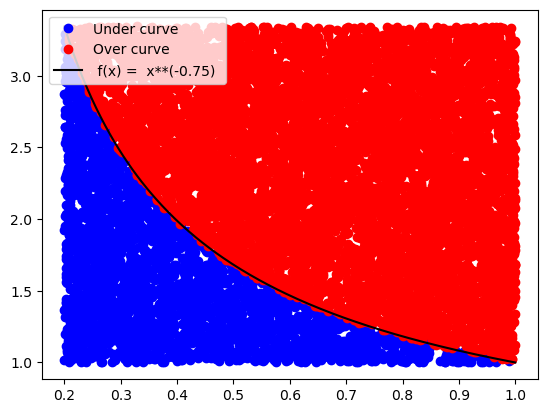

In [42]:


x = sp.symbols('x')
func_exp = x**(-3/4)

a = 0
b = 1
n = 10000
h = (b-a)/n

# Convert the symbolic expression to a numerical function
func = sp.lambdify(x, func_exp, 'numpy')

# Define the range of x values, avoiding x = 0
x_vals = np.linspace(0.1, 1, 500)  # Start slightly above 0 to avoid singularity
y_vals = func(x_vals)
plt.plot(x_vals, y_vals, label=r"$f(x) = \frac{1}{\sqrt{x}}$", color="blue")
plt.show()

I1 = monte_carlo(func_exp,a,b,n)

true_value = sp.integrate(func_exp, (x,a,b))

error_value = abs(I1 - true_value)

print(f"Integral of {func_exp} from {a} to {b} for n = {n} is  = {I1}")
print(f"True value of integral of {func_exp} from {a} to {b} is  = {true_value}")
print(f"Error in the value of integral is = {error_value}")



## Q2. Numerical Root Finding

Find all the roots of the following equation using the Newton-Raphson Method:


$$ (x - a)^2 \left( 1 + \frac{x - b}{a - b} \right) + \alpha (x - b)^2 \left( 1 + \frac{x - a}{b - a} \right) = 0 $$

Try starting with values \( x = a \) or \( x = b \). Use $ \alpha = \pm 1 $,  $a = 1 $, and $ b = 2 $.

Prove that, if no round off error, then the iteration will keep oscillating between x=a and x=b

In [ ]:
x = sp.symbols('x')

a = sp.symbols('a')
b = sp.symbols('b')
alpha = sp.symbols('alpha')

func_exp = (x-a)**2 * (1+(x-b)/(a-b)) + alpha*(x-b)**2 * (1+ (x-a)/(b-a))

func_exp

func_exp_d1 = sp.diff(func_exp,x)



alpha*(1 + (-a + x)/(-a + b))*(-b + x)**2 + (1 + (-b + x)/(a - b))*(-a + x)**2

In [ ]:
import sympy as sp
import numpy as np
from scipy.optimize import newton

# Define symbols
x = sp.symbols('x')
a, b, alpha = sp.symbols('a b alpha')

a,b,alpha = 1,2,-1
# Define the function expression
func_exp = (x - a)**2 * (1 + (x - b) / (a - b)) + alpha * (x - b)**2 * (1 + (x - a) / (b - a))

#func_exp = x**2 - 2*x + 1
# Differentiate the function with respect to x
func_exp_d1 = sp.diff(func_exp, x)

# Lambdify the function and its derivative for numerical evaluation
func = sp.lambdify(x, func_exp, 'numpy')
func_prime = sp.lambdify(x, func_exp_d1, 'numpy')

# Set parameters
a_val = 0
b_val = 2.2

# Initial guesses for x
x0_a = a_val
x0_b = b_val

# Use scipy.optimize.newton to find roots starting from x = a and x = b
try:
    root_from_a = newton(func, x0_a, fprime=func_prime)
    root_from_b = newton(func, x0_b, fprime=func_prime)
except RuntimeError as e:
    print(f"Error finding root: {e}")

# Output results
print(f"Root starting from x = a: {root_from_a}")
print(f"Root starting from x = b: {root_from_b}")



Root starting from x = a: 0.38196601125010515
Root starting from x = b: 2.618033988749895


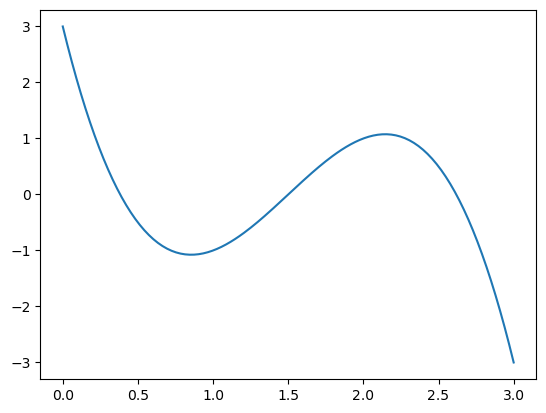

In [81]:
xline = np.linspace(a_val, b_val, 200)
yline = func(xline)
plt.plot(xline, yline, label='f(x)')

In [85]:
func(2)

1

## Q Ordinary Differential Equation & it’s Stability:
 

### (a) Consider a initial value problem $y' = y + t - t^3$, $y(0) = 5$. Suppose we use Euler’s method with step size $h$ to compute the approximation solution $y = y(t_i)$; $t_j = jh$. Find an explicit formula for $y_i$ and obtain the truncation error. Show that for a fixed value of $t$, the error goes to zero as $h \to 0$. 

In [16]:
import sympy as sp

# Define the independent variable and the dependent function
t = sp.symbols('t')
y = sp.Function('y')(t)

# Define the differential equation
diff_eq = sp.Eq(sp.Derivative(y, t), y + t - t**3)

# Solve the differential equation
solution = sp.dsolve(diff_eq, y)

# Display the solution
print("General Solution:")
print(solution)

# Define the initial condition y(0) = 5
ics = {y.subs(t, 0): 5}

# Solve with initial condition
particular_solution = sp.dsolve(diff_eq, y, ics=ics)

# Display the particular solution
print("\nParticular Solution:")
print(particular_solution)


General Solution:
Eq(y(t), C1*exp(t) + t**3 + 3*t**2 + 5*t + 5)

Particular Solution:
Eq(y(t), t**3 + 3*t**2 + 5*t + 5)


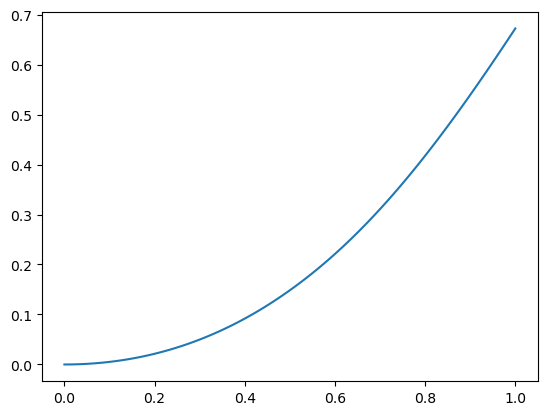

In [ ]:
#import initial value problem
from scipy.integrate import solve_ivp


def dy_dt(y,t):
    return y + t-t**3

y0 = 0
t_line = np.linspace(0,1,100)
sol = solve_ivp(dy_dt,[0,1],[y0],t_eval = t)
plt.plot(sol.t,sol.y[0],label = 'y(t)')



In [30]:
def euler(f,intitial):
    [x0,y0,h,b] = intitial
    x = np.linspace(x0,b,int((b-x0)/h))
    y = np.zeros(len(x))
    y[0] = y0
    for i in range(len(x)-1):
        y[i+1] = y[i] + h*f(y[i],x[i])
    return x,y

def numerical_int(f,intitial):
    [x0,y0,h,b] = intitial
    x = np.linspace(x0,b,int((b-x0)/h))
    y = np.zeros(len(x))
    y[0] = y0
    for i in range(len(x)-1):
        y[i+1] = y[i] + 2*h*f(y[i],x[i])
    return x,y


[0.1, 0.01, 0.001, 0.0001, 1e-05, 1e-06]
error at t =1 for h = 0.1 is  = 1.9031238327914934
error at t =1 for h = 0.01 is  = 0.2124397156499267
error at t =1 for h = 0.001 is  = 0.021492523156386056
error at t =1 for h = 0.0001 is  = 0.0021517683050458203
error at t =1 for h = 1e-05 is  = 0.00035730636249198255
error at t =1 for h = 1e-06 is  = 2.1520452888168506e-05


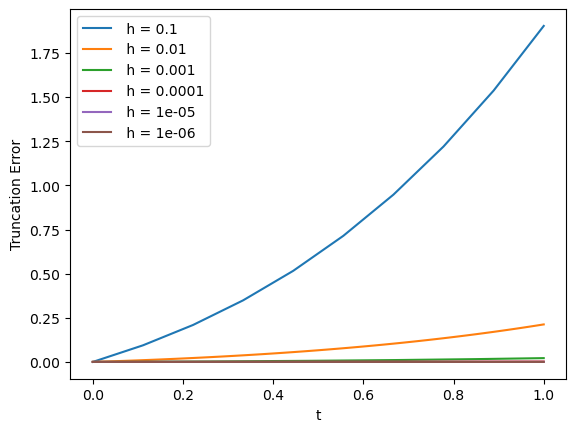

In [39]:
hs = [ 1/(10**x) for x in np.linspace(1,6,6)  ]
#hs = [ 1/(5**x) for x in np.linspace(1,8,8) ]

print(hs)
x0 = 0
y0 = 5
b = 1 
for h in hs:
    initial = [x0,y0,h,b]
    x_ans,y_ans = euler(dy_dt,initial)
    analytical = sp.lambdify(t, particular_solution.rhs,  'numpy' )

    error = abs(analytical(x_ans) - y_ans)
    plt.plot(x_ans,error,label = f" h = {h}")
    print(f'error at t =1 for h = {h} is  = {error[-1]}')

plt.legend()
plt.xlabel("t")
plt.ylabel("Truncation Error")
plt.show()

    

###  (b) Repeat the above exercise for the numerical integration method $y_{j+1} = y_j + 2h y_j'$ and show that the truncation error does not tend to zero as $h \to 0$. Why?


[0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625, 0.0078125, 0.00390625]
error at t =1 for h = 0.5 is  = 4.0
error at t =1 for h = 0.25 is  = 3.2824074074074083
error at t =1 for h = 0.125 is  = 10.596111508917186
error at t =1 for h = 0.0625 is  = 16.280116771478948
error at t =1 for h = 0.03125 is  = 19.940503052770715
error at t =1 for h = 0.015625 is  = 22.03871330033347
error at t =1 for h = 0.0078125 is  = 23.165238986924734
error at t =1 for h = 0.00390625 is  = 23.749363048575724


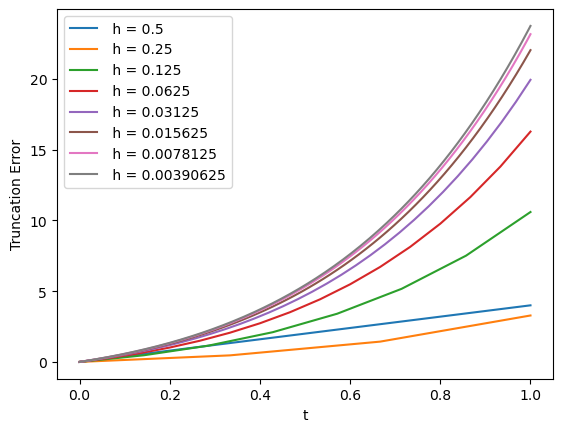

In [36]:
hs = [ 1/(2**x) for x in np.linspace(1,8,8) ]
print(hs)
x0 = 0
y0 = 5
b = 1 
for h in hs:
    initial = [x0,y0,h,b]
    x_ans,y_ans = numerical_int(dy_dt,initial)
    analytical = sp.lambdify(t, particular_solution.rhs,  'numpy' )

    error = abs(analytical(x_ans) - y_ans)
    plt.plot(x_ans,error,label = f" h = {h}")
    print(f'error at t =1 for h = {h} is  = {error[-1]}')

plt.legend()
plt.xlabel("t")
plt.ylabel("Truncation Error")
plt.show()

    

## Q 4. Analyse the stability of fourth-order Runge-Kutta Method.

## Q 5. Richardson Extrapolation: 
Use Richardson extrapolation to estimate the first derivative of $\sin^2{x}$ at $x = \pi/4$ using step sizes of $h_1 = \pi/5$ and $h_2 = \pi/10$. Use centred differences of $O(h_2)$ for the initial estimates.

### Q 6. Spline Interpolation

The following table gives the vapour pressure of water as a function of temperature:

| Temperature (°C) | Vapour Pressure (mm of Hg) |
|------------------|----------------------------|
| 0                | 4.579                      |
| 5                | 6.543                      |
| 10               | 9.209                      |
| 15               | 12.788                     |
| 20               | 17.535                     |
| 25               | 23.756                     |
| 30               | 31.824                     |
| 35               | 41.175                     |
| 40               | 55.324                     |

Using the cubic interpolation method, estimate the value of vapour pressure at the following temperatures
 -5, -1, 1, 13, 22, 37,and 45 ,$^\circ$ C

Try to estimate the accuracy of computations and verify the results by comparing them with the known values 3.163, 4.258, 4.926, 11.231, 19.827, 47.067, and 71.88  respectively


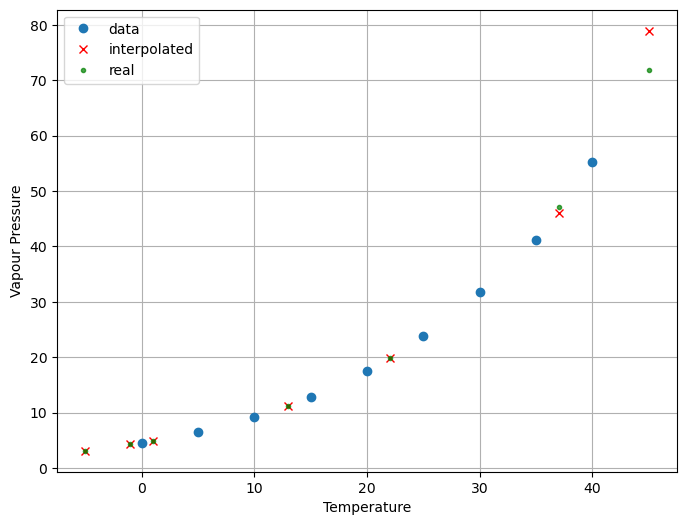

[3.75487179e-02 4.41628718e-03 1.16566154e-03 1.55425641e-03
 2.24059897e-02 1.07003381e+00 7.06731795e+00]


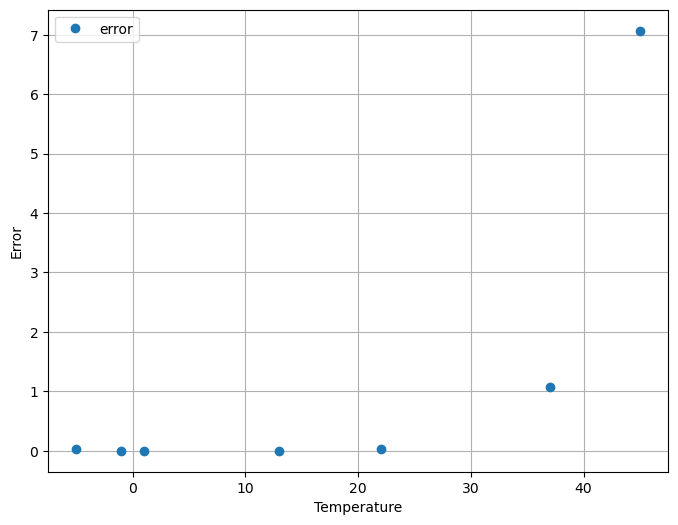

In [5]:
from scipy.interpolate import CubicSpline


Temperature = np.arange(0,45,5)
Vapour_Pressure = [4.579,6.543,9.209,12.788,17.535,23.756,31.824,41.175,55.324]

test_temp = [-5, -1, 1, 13, 22, 37,45]
known_VP = [3.163, 4.258, 4.926, 11.231, 19.827, 47.067 , 71.88]


cs = CubicSpline(Temperature, Vapour_Pressure)

VP = cs(test_temp)

plt.figure(figsize = (8,6))
plt.plot(Temperature, Vapour_Pressure, 'o', label='data')
plt.plot(test_temp, VP, 'x',color = "r", label='interpolated')
plt.plot(test_temp, known_VP, '.',color = "g",alpha = 0.7, label='real')
plt.xlabel('Temperature')
plt.ylabel('Vapour Pressure')
plt.legend()
plt.grid()
plt.show()

error = np.abs(known_VP - VP)
print(error)

plt.figure(figsize = (8,6))
plt.plot(test_temp, error, 'o', label='error')
plt.xlabel('Temperature')
plt.ylabel('Error')
plt.legend()
plt.grid()
